In [62]:
# load libraries and load date
# ----------------------------
import pandas as pd
customers = pd.read_csv("C:/Users/gcart/OneDrive/Documents/dev/r/projs/book_reviews/solve_any_data_analysis_problem_projs/CH02_asboth_Solve_Any_Data_Analysis_Problem/data/addresses.csv")
print(customers.shape)

(100000, 3)


In [63]:
# check for missing data
# ----------------------
customers.isnull().sum()

company_id       0
address        968
total_spend      0
dtype: int64

In [64]:
# drop rows with missing data
# ---------------------------
customers.dropna(subset=["address"], inplace=True)

# check
print(customers.shape)

(99032, 3)


In [65]:
# check for negative total_spend values
customers["total_spend"].describe()

count    99032.000000
mean      4951.673197
std       1500.642398
min          0.000000
25%       3900.000000
50%       5000.000000
75%       6000.000000
max      11700.000000
Name: total_spend, dtype: float64

In [66]:
# observe and review address structure
for address in customers["address"].head():
    print(address, "\n")

APARTMENT 2,
52 BEDFORD ROAD,
LONDON,
ENGLAND,
SW4 7HJ 

107 SHERINGHAM AVENUE,
LONDON,
N14 4UJ 

43 SUNNINGDALE,
YATE,
BRISTOL,
ENGLAND,
BS37 4HZ 

HAWESWATER HOUSE,
LINGLEY MERE BUSINESS PARK,
LINGLEY GREEN AVENUE,
GREAT SANKEY, WARRINGTON,
WA5 3LP 

AMBERFIELD BARN HOUSE AMBER LANE,
CHART SUTTON,
MAIDSTONE,
ENGLAND,
ME17 3SF 



In [67]:
# change all address characters to upper case to
# avoid inconsistant application of case for different
# address spellings; this makes searching more 'accurate'
customers["address_clean"] = customers["address"].str.upper()

# check
customers.head()

,company_id,address,total_spend,address_clean
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA..."
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ"
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS..."
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,..."
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO..."


In [68]:
# "investigate the difference between looking for “LONDON” and “LONDON,"
len(customers[customers["address_clean"].str.contains("LONDON")])

21768

In [69]:
len(customers[customers["address_clean"].str.contains("LONDON,")])

20831

In [70]:
# "Let’s look at how many addresses consist of how many rows."
customers["address_lines"] = (
    customers["address_clean"]
    # Split an address into a list of substrings, i.e separate the rows
    .str.split(",\n")
    # Count the length of each list, i.e. the number of rows in the address
    .apply(len)
) 

# Now count up how many addresses are made of how many rows
customers["address_lines"].value_counts().sort_index()

1        6
2       52
3     3284
4    35850
5    45931
6    13909
Name: address_lines, dtype: int64

In [71]:
# "We should also examine some of these shorter addresses to see what they look like"
print(customers.loc[customers["address_lines"] == 1, "address_clean"])
print((
    customers[customers["address_lines"] == 2]
    # Look at 5 random rows that have only 2 lines of address
    .sample(5, random_state=42)
    ["address_clean"])
)

17789                      FALKIRK
31897                   HADDINGTON
61750          CREAG BHAITHEACHAIN
75330                     NEWMILNS
78045    REDCLOAK FARM, STONEHAVEN
90897     REFER TO PARENT REGISTRY
Name: address_clean, dtype: object
39443                                    FORFAR,\nANGUS
80846                        12 HOPE STREET,\nEDINBURGH
95979    BRANCH REGISTRATION,\nREFER TO PARENT REGISTRY
23563    BRANCH REGISTRATION,\nREFER TO PARENT REGISTRY
81155                             PO BOX 2230,\nGLASGOW
Name: address_clean, dtype: object


In [72]:
# Import the cities data that was extracted from  
# https://www.gov.uk/government/publications/list-of-cities/list-of-cities-html 
# and cleaned
cities = pd.read_csv("C:/Users/gcart/OneDrive/Documents/dev/r/projs/book_reviews/solve_any_data_analysis_problem_projs/CH02_asboth_Solve_Any_Data_Analysis_Problem/data/cities.csv", header=None, names=["city"])
cities.head()


# Search for the term 'England' within the 'city' column
england_cities = cities[cities['city'].str.contains('England')]
# Display the result
print(england_cities)

      city
0  England


In [73]:
# cleanup cities table

# remove country names from list
countries_to_remove = ["England", "Scotland", "Wales", "Northern Ireland"]
print(len(cities))
cities_to_remove = cities[cities["city"].isin(countries_to_remove)].index
cities = cities.drop(index=cities_to_remove)
print(len(cities))

# remove asterisks
cities["city"] = cities["city"].str.replace("*", "", regex=False)

# covert cities to uppercase
cities["city"] = cities["city"].str.upper()

# Search for the term 'England' within the 'city' column
england_cities = cities[cities['city'].str.contains('England')]
# Display the result
print(england_cities)


80
76
Empty DataFrame
Columns: [city]
Index: []


In [74]:
# "use this list to tag an address with a particular city if that city name, and an additional comma, 
#  are found somewhere in the address. Anything where this newly-created city column doesn’t have a 
# value, where a city name was not found, will be categorized as “Other”.

for city in cities["city"].values:
    customers.loc[customers["address_clean"].str.contains(f"\n{city},"),"city"] = city

customers["city"].fillna("OTHER", inplace=True)
 
customers.head()


,company_id,address,total_spend,address_clean,address_lines,city
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5,LONDON
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",3,LONDON
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5,BRISTOL
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",5,OTHER
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",5,OTHER


In [75]:
# look at the top 20
customers["city"].value_counts().head(20)

OTHER            54458
LONDON           20762
MANCHESTER        1902
BIRMINGHAM        1866
GLASGOW           1273
BRISTOL           1150
LEEDS             1040
EDINBURGH         1038
LEICESTER          905
NOTTINGHAM         838
LIVERPOOL          838
CARDIFF            797
SHEFFIELD          706
COVENTRY           553
MILTON KEYNES      493
SOUTHAMPTON        477
NORWICH            449
BRADFORD           417
BELFAST            416
PRESTON            406
Name: city, dtype: int64

In [76]:
# "...half of our customer base is based outside of major cities. This is an important insight to 
# communicate to our stakeholders. Let’s look at some addresses from this category
sample_other = customers[customers["city"] == "OTHER"].sample(5, random_state=42)
for address in sample_other["address_clean"].values:
    print(address, "\n")

82 CROSSE COURTS,
BASILDON,
ENGLAND,
SS15 5JE 

70 NORMAN CRESCENT,
PINNER,
ENGLAND,
HA5 3QL 

23 STATION ROAD,
GERRARDS CROSS,
BUCKINGHAMSHIRE,
ENGLAND,
SL9 8ES 

5 STEWARTS PARK AVENUE,
MARTON,
MIDDLESBROUGH,
CLEVELAND,
UNITED KINGDOM,
TS4 3FD 

FIRST FLOOR,
6 YORK STREET,
TWICKENHAM,
ENGLAND,
TW1 3LD 



In [77]:
# "Depending on the business, we might assume that we have at least one customer in every major UK city, and we can verify 
#  this."
set(cities["city"]) - set(customers["city"])

{'KINGSTON-UPON-HULL'}

In [78]:
# "The result is that the city Kingston-upon-Hull is not in the city column of our customer address 
#  data. Either this means we have no customers there, which is not impossible given its population 
#  is only around 250,000, or there is something else going on. The city is usually abbreviated to 
#  just “Hull”, and if we look for this city in our data we find 284 records."
customers[customers["address_clean"].str.contains("\nHULL,")]

,company_id,address,total_spend,address_clean,address_lines,city
455,456,"349 BEVERLEY ROAD,\nANLABY,\nHULL,\nENGLAND,\n...",3800,"349 BEVERLEY ROAD,\nANLABY,\nHULL,\nENGLAND,\n...",5,OTHER
1139,1140,"90 CALVERT LANE,\nHULL,\nENGLAND,\nHU4 6BJ",6000,"90 CALVERT LANE,\nHULL,\nENGLAND,\nHU4 6BJ",4,OTHER
1822,1823,"ACER GLADE BLACK TUP LANE,\nARNOLD,\nHULL,\nEN...",4600,"ACER GLADE BLACK TUP LANE,\nARNOLD,\nHULL,\nEN...",5,OTHER
1831,1832,"10 GORDON STREET,\nHULL,\nENGLAND,\nHU3 3HN",5300,"10 GORDON STREET,\nHULL,\nENGLAND,\nHU3 3HN",4,OTHER
1921,1922,"70 WRIGHT STREET,\nHULL,\nENGLAND,\nHU2 8JD",6100,"70 WRIGHT STREET,\nHULL,\nENGLAND,\nHU2 8JD",4,OTHER
...,...,...,...,...,...,...
98479,98480,"31-38 QUEEN STREET,\nHULL,\nENGLAND,\nHU1 1UU",4500,"31-38 QUEEN STREET,\nHULL,\nENGLAND,\nHU1 1UU",4,OTHER
98886,98887,"13 SALMON GROVE,\nHULL,\nEAST YORKSHIRE,\nENGL...",5000,"13 SALMON GROVE,\nHULL,\nEAST YORKSHIRE,\nENGL...",5,OTHER
99196,99197,"22 19TH AVENUE,\nHULL,\nENGLAND,\nHU6 8HF",5900,"22 19TH AVENUE,\nHULL,\nENGLAND,\nHU6 8HF",4,OTHER
99434,99435,"F14 THE BLOC SPRINGFIELD WAY,\nANLABY,\nHULL,\...",3100,"F14 THE BLOC SPRINGFIELD WAY,\nANLABY,\nHULL,\...",6,OTHER


In [79]:
# "update our city column to fix this issue."
customers.loc[customers["address_clean"].str.contains("\nHULL,"),"city"] = "HULL"

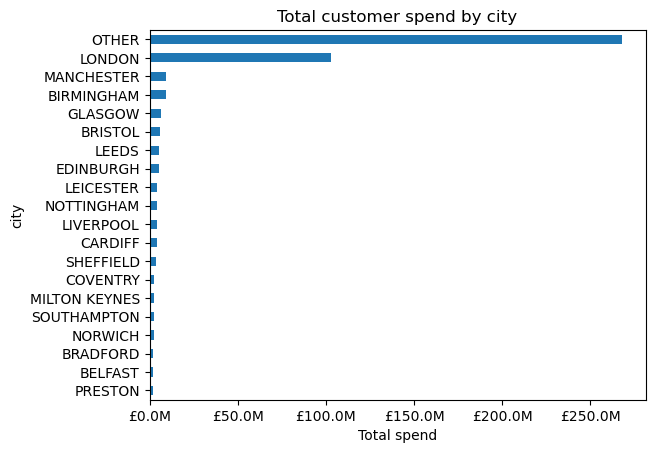

In [80]:
# "output chart"
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
 
def millions(x, pos):
    return '£%1.1fM' % (x * 1e-6)
 
formatter = FuncFormatter(millions)
 
fig, axis = plt.subplots()
 
top_20_spend = (
    customers
    .groupby("city")
    ["total_spend"].sum()
    .sort_values(ascending=False)
    .head(20)
    .sort_values(ascending=True)
)
 
top_20_spend.plot.barh(ax=axis)
 
axis.xaxis.set_major_formatter(formatter)
axis.set(
    title="Total customer spend by city",
    xlabel="Total spend"
)
 
plt.show()

In [81]:
# "compare London against the rest of the UK"
print("Total spend for London customers:")
print(customers.loc[customers["city"] == "LONDON", "total_spend"].sum())
 
print("Total spend outside London:")
print(customers.loc[customers["city"] != "LONDON", "total_spend"].sum())
 
print("Total spend outside London (excluding OTHER):")
print(customers.loc[customers["city"].isin(["LONDON", "OTHER"]) == False,"total_spend"].sum())

Total spend for London customers:
103042800
Total spend outside London:
387331300
Total spend outside London (excluding OTHER):
119468400
